# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

---

### Aim
To implement K-Nearest Neighbours (KNN) classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Furthermore, to perform a comparative study between classification evaluation metrics and regression evaluation metrics studied in Linear Regression (Lab 3).

### Dataset Description
**Breast Cancer Wisconsin (Diagnostic) Dataset**
- **Samples:** 569
- **Features:** 30 numerical features describing characteristics of the cell nuclei present in the digitized image of a fine needle aspirate (FNA) of a breast mass.
- **Target:** Diagnostic label `y` where:
  - `0` $\rightarrow$ Malignant
  - `1` $\rightarrow$ Benign


## Task 1: Data Preparation

In this section, we will:
1. Load the dataset from the local `brca.csv` file.
2. Explore the dataset's structure, check shapes, and inspect data types.
3. Check for missing values and duplicate rows.
4. Convert the target variable `y` (`'B'` $\rightarrow 1$, `'M'` $\rightarrow 0$).
5. Apply feature scaling using `StandardScaler` and provide a justification for its importance in KNN.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_curve, auc
)

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')  # clean layout style
sns.set_palette('muted')

print('Libraries imported successfully.')


Libraries imported successfully.


In [2]:
# 1.1 Load the dataset
# The first column is an index column, so we set index_col=0
try:
    df = pd.read_csv('brca.csv', index_col=0)
    print('Dataset loaded successfully!')
except FileNotFoundError:
    print('Error: brca.csv not found in the current directory.')

# 1.2 Explore structure
print(f'Dataset Shape: {df.shape}')
print('\nFirst 5 rows:')
display(df.head())
print('\nData Types and Info:')
df.info()


Dataset loaded successfully!
Dataset Shape: (569, 31)

First 5 rows:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 1 to 569
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     56

In [3]:
# 1.3 Check for missing values and duplicate rows
missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f'Total Missing Values: {missing_values}')
print(f'Total Duplicate Rows: {duplicate_rows}')

# Inspect class distribution
print('\nTarget Label Distribution before mapping:')
print(df['y'].value_counts())


Total Missing Values: 0
Total Duplicate Rows: 0

Target Label Distribution before mapping:
y
B    357
M    212
Name: count, dtype: int64


### Target Mapping
As per the lab requirements, we map:
- `B` (Benign) $\rightarrow 1$
- `M` (Malignant) $\rightarrow 0$


In [4]:
# Map target labels
df['y'] = df['y'].map({'M': 0, 'B': 1})
print('Target variable successfully mapped.')
print('Target distribution post-mapping:')
print(df['y'].value_counts())


Target variable successfully mapped.
Target distribution post-mapping:
y
1    357
0    212
Name: count, dtype: int64


### Feature Scaling Justification
**Why is feature scaling required in KNN?**
K-Nearest Neighbours is a distance-based machine learning algorithm. It calculates distances (e.g., Euclidean or Manhattan) between data points to identify the 'K' nearest neighbours. 
If features have different scales (for instance, one feature ranges from 0 to 1 and another ranges from 100 to 1000), the feature with the larger magnitude will dominate the distance calculations. This makes the model insensitive to variables with smaller scales, regardless of their actual predictive power. 

Applying feature scaling (e.g., `StandardScaler`, which standardizes features to have a mean of 0 and variance of 1) ensures that all features contribute equally to the distance computation.


In [5]:
# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Features successfully scaled.')
print('\nScaled Feature Summary (First 5 rows):')
display(X_scaled_df.head(2))


Features successfully scaled.

Scaled Feature Summary (First 5 rows):


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250


## Task 2: Train-Test Split Analysis

We will split the dataset into training and testing sets using three different ratios:
1. **80:20** (Standard)
2. **70:30**
3. **90:10**

For each split, we will fit a baseline KNN classifier ($K=5$) and evaluate performance variations across splits. We will then analyze how dataset splitting affects model stability and generalization.


In [6]:
splits = [(0.20, '80:20'), (0.30, '70:30'), (0.10, '90:10')]
split_results = []

for test_size, name in splits:
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Train KNN model with K=5
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    
    # Predict
    y_train_pred = knn_temp.predict(X_train)
    y_test_pred = knn_temp.predict(X_test)
    
    # Evaluate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    split_results.append({
        'Split': name,
        'Train Size': X_train.shape[0],
        'Test Size': X_test.shape[0],
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Test Precision': test_prec,
        'Test Recall': test_rec,
        'Test F1-Score': test_f1
    })

# Display results as a DataFrame
df_splits = pd.DataFrame(split_results)
display(df_splits)


,Split,Train Size,Test Size,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,80:20,455,114,0.973626,0.964912,0.959459,0.986111,0.972603
1,70:30,398,171,0.969849,0.970760,0.955357,1.000000,0.977169
2,90:10,512,57,0.980469,0.982456,0.972973,1.000000,0.986301


### Split Analysis
- **90:10 Split:** Provides the most training data (512 samples). This helps the model learn patterns thoroughly, but the test set size is small (57 samples), making evaluation metrics highly sensitive to individual test instances (higher variance in evaluation).
- **80:20 Split:** Represents a standard, balanced split. It provides sufficient training data (455 samples) and a large enough test set (114 samples) to ensure stable evaluation metrics.
- **70:30 Split:** Provides a larger test set (171 samples) for highly stable validation metrics, but reduces the training dataset size (398 samples), which might lead to slightly lower training performance or underfitting.

**Effect on Generalization and Stability:**
If the training set is too small (e.g. 50:50 or 60:40), the model may underfit and fail to generalize well. If the training set is too large (e.g. 95:5), the test set is too small to provide a reliable estimate of generalization performance; a few wrong predictions on the test set will dramatically sway performance metrics. An **80:20** split offers a reliable trade-off between training capacity and evaluation stability.


## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection
A common rule of thumb for selecting the initial $K$ in KNN is setting $K = \sqrt{n}$, where $n$ is the number of training samples. 
For the standard 80:20 split, we compute the baseline $K$ as follows:


In [7]:
# Split using standard 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

n_samples = X_train.shape[0]
heuristic_k = int(np.sqrt(n_samples))

print(f'Number of training samples (n): {n_samples}')
print(f'Calculated Heuristic K (sqrt(n)): {np.sqrt(n_samples):.4f}')
print(f'Baseline K selected: {heuristic_k}')
if heuristic_k % 2 == 0:
    print(f'Note: {heuristic_k} is even. To avoid voting ties, an odd K is usually preferred. Let\'s check neighboring values.')


Number of training samples (n): 455
Calculated Heuristic K (sqrt(n)): 21.3307
Baseline K selected: 21


### 3.2 Model Training and Hyperparameter Tuning ($K \pm 5$)
We train KNN models on our 80:20 split with $K$ values ranging from $K - 5$ to $K + 5$ around the heuristic value ($K = 21$). The range is $[16, 26]$. We plot the training and testing accuracies to identify the optimal $K$ based on performance trends.


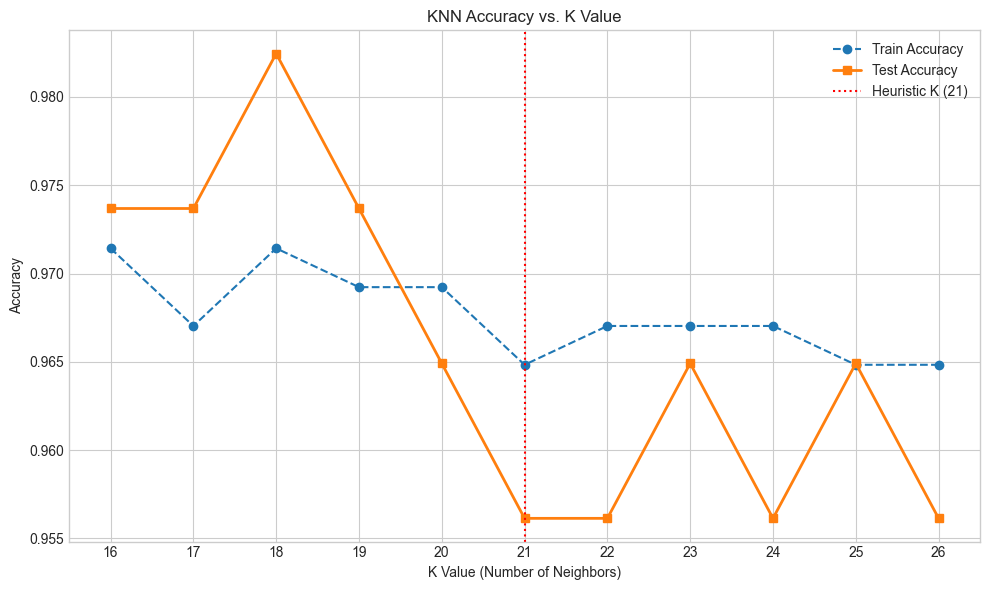

,K,Train Accuracy,Test Accuracy
0,16,0.971429,0.973684
1,17,0.967033,0.973684
2,18,0.971429,0.982456
3,19,0.969231,0.973684
4,20,0.969231,0.964912
5,21,0.964835,0.956140
6,22,0.967033,0.956140
7,23,0.967033,0.964912
8,24,0.967033,0.956140
9,25,0.964835,0.964912


In [8]:
k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Record accuracies
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

# Plot Accuracy vs K
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy', color='#1f77b4', linestyle='--')
plt.plot(k_values, test_accuracies, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2)
plt.axvline(x=heuristic_k, color='red', linestyle=':', label=f'Heuristic K ({heuristic_k})')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. K Value')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

# Display results as table
df_k_tuning = pd.DataFrame({
    'K': k_values,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})
display(df_k_tuning)


### 3.3 Distance Metrics & Decision Boundary Mapping

#### Explanation of Distance Metrics

1. **Euclidean Distance:**
   - **Formula:** $d(x, y) = \sqrt{\sum_{i=1}^{d} (x_i - y_i)^2}$
   - **Suitability:** It represents the straight-line distance between two points in Euclidean space. It works best when the features are continuous, dense, and properly scaled. However, it is highly sensitive to extreme outliers and the curse of dimensionality (in very high dimensions, distances become sparse).

2. **Manhattan Distance (L1 norm / Taxicab distance):**
   - **Formula:** $d(x, y) = \sum_{i=1}^{d} |x_i - y_i|$
   - **Suitability:** It represents distance computed by traversing along grid lines at right angles. It is suitable when features are discrete/binary, or when the data is high-dimensional (it can be more robust to the curse of dimensionality than Euclidean). It is also preferred when features are measured on different grid-like axes (e.g., path routing in a city grid).

#### Decision Boundary Visualization
To visualize the decision boundary of KNN, we will train a separate KNN classifier using only two features: `x.radius_mean` and `x.texture_mean`. Training a model on these two scaled features allows us to plot the boundary on a 2D plane for $K = 1, 5, 10, 20$.


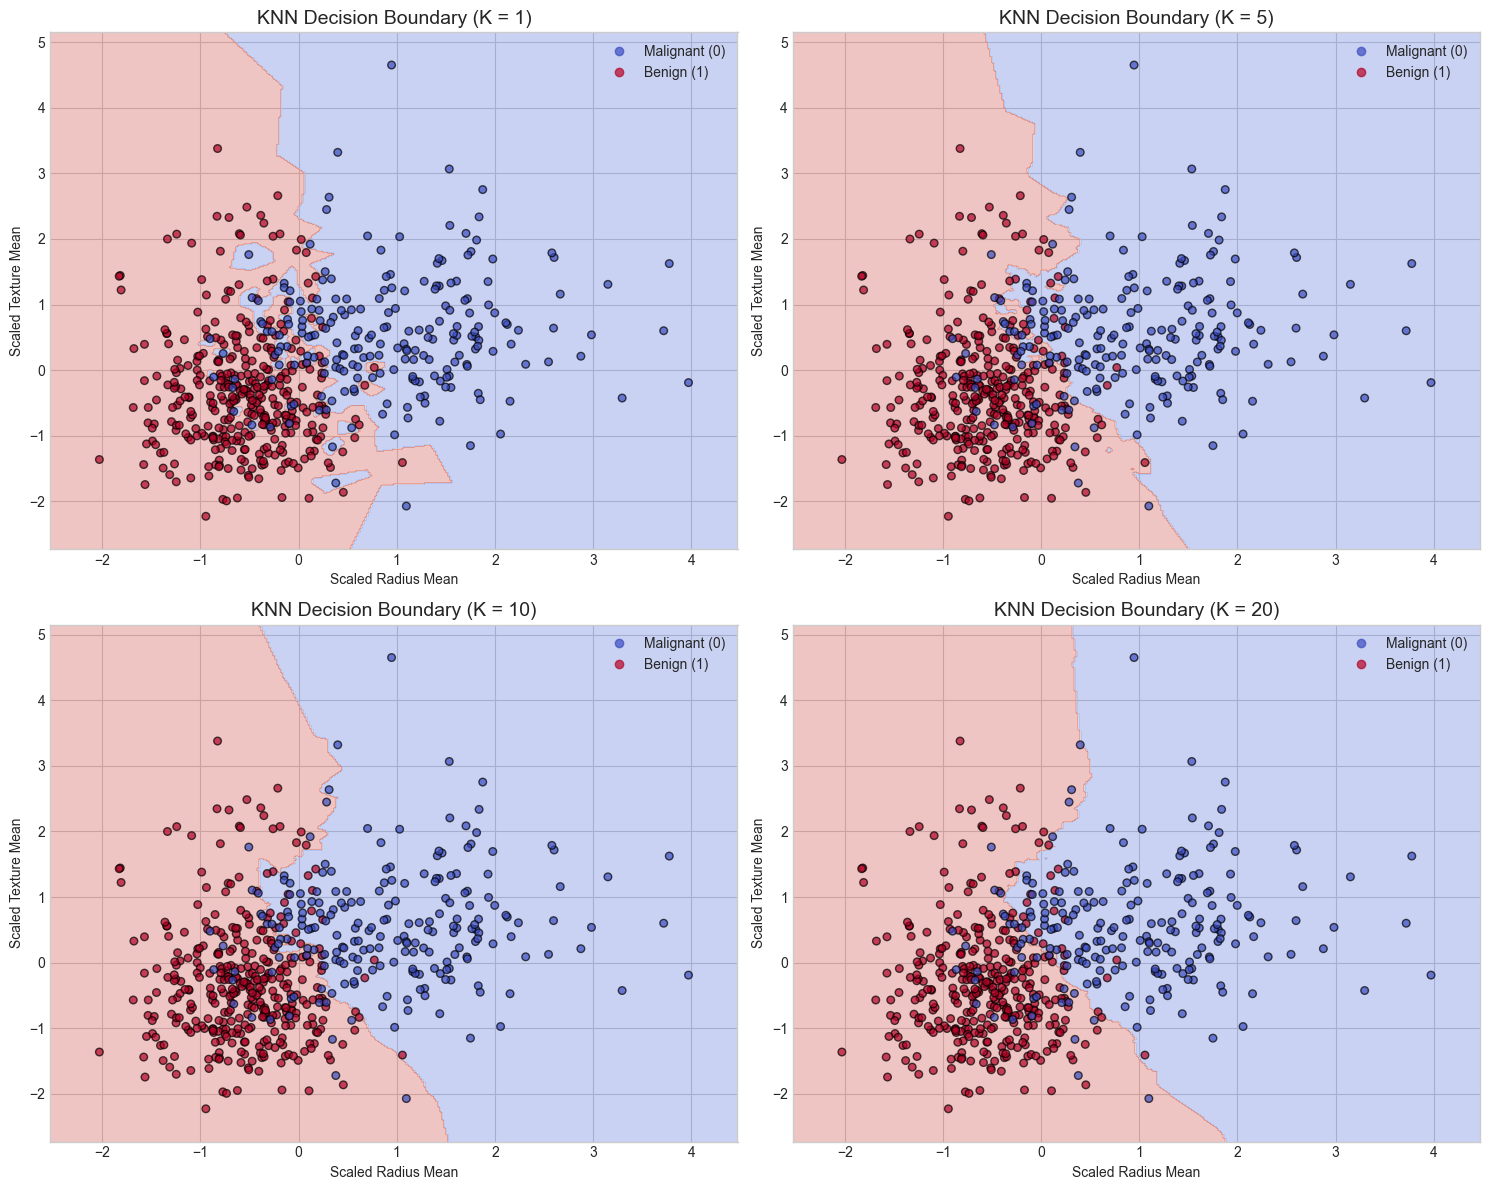

In [9]:
# Select two features: radius_mean (col index 0) and texture_mean (col index 1)
X_2d = X_scaled[:, :2]  # x.radius_mean and x.texture_mean
y_2d = y.values

# Define the K values to visualize
k_viz = [1, 5, 10, 20]

# Define meshgrid bounds
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, k in enumerate(k_viz):
    # Fit KNN on 2D data
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d, y_2d)
    
    # Predict over meshgrid
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundaries
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # Scatter plot of training points
    # Malignant = 0 (red), Benign = 1 (blue)
    scatter = axes[idx].scatter(
        X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='coolwarm', 
        edgecolors='k', s=30, alpha=0.7
    )
    
    # Labels & Title
    axes[idx].set_title(f'KNN Decision Boundary (K = {k})', fontsize=14)
    axes[idx].set_xlabel('Scaled Radius Mean', fontsize=10)
    axes[idx].set_ylabel('Scaled Texture Mean', fontsize=10)
    
    # Legend
    handles, labels = scatter.legend_elements()
    axes[idx].legend(handles, ['Malignant (0)', 'Benign (1)'], loc='upper right')

plt.tight_layout()
plt.show()


### Decision Boundary Analysis
- **K = 1:** The decision boundary is highly complex, jagged, and closely follows every single training data point. This indicates **overfitting** (high variance, low bias). The model fits noise in the dataset, leading to potential misclassifications on unseen data.
- **K = 5 & K = 10:** The boundaries start to smooth out. The model ignores localized noise and focuses on the general distributions of classes. This indicates a good balance between bias and variance.
- **K = 20:** The boundary is very smooth. Small islands of classes are ignored in favor of a global trend. While this reduces variance, it might lead to **underfitting** (high bias), where the model oversimplifies the boundaries between Malignant and Benign classes.


## Task 4: Cross Validation

To obtain a robust estimate of optimal $K$ and avoid overfitting to our specific train-test split, we perform K-Fold Cross-Validation. We will apply **10-Fold Cross-Validation** over a range of $K$ values ($K = 1$ to $K = 30$) and plot the mean cross-validation accuracy.


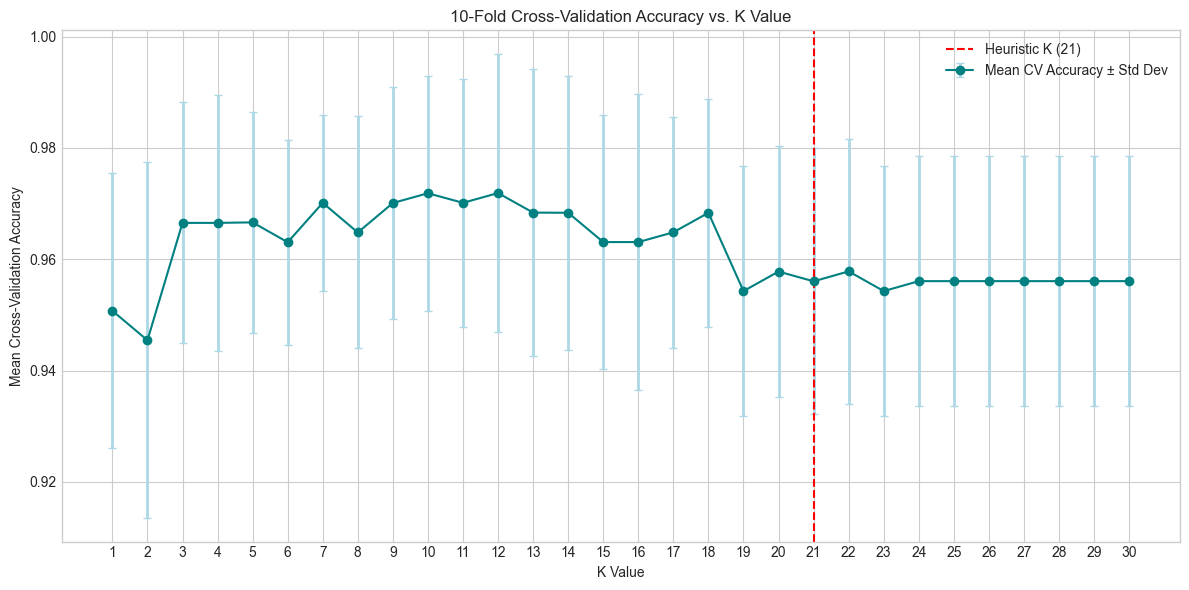

Optimal K from Cross-Validation: 12 with Mean Accuracy: 0.9719


In [10]:
k_range = list(range(1, 31))
cv_scores_mean = []
cv_scores_std = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # Perform 10-Fold Cross Validation
    scores = cross_val_score(knn_cv, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

# Plot CV Accuracy vs K
plt.figure(figsize=(12, 6))
plt.errorbar(k_range, cv_scores_mean, yerr=cv_scores_std, fmt='-o', color='teal', 
             ecolor='lightblue', elinewidth=2, capsize=3, label='Mean CV Accuracy ± Std Dev')
plt.axvline(x=heuristic_k, color='red', linestyle='--', label=f'Heuristic K ({heuristic_k})')
plt.xlabel('K Value')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('10-Fold Cross-Validation Accuracy vs. K Value')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

# Identify best K from CV
best_cv_k = k_range[np.argmax(cv_scores_mean)]
best_cv_score = max(cv_scores_mean)
print(f'Optimal K from Cross-Validation: {best_cv_k} with Mean Accuracy: {best_cv_score:.4f}')


### Cross Validation vs. Train-Test Split Results
A single train-test split can be biased based on which instances end up in the training or testing partition. Cross-validation divides the dataset into $M$ folds, iteratively trains on $M-1$ folds, and tests on the remaining fold. This ensures that every data point is used for validation exactly once, giving a highly reliable, generalizable performance estimate.

**Selection of Final Optimal K:**
Based on both our heuristic rule ($K = \sqrt{569} \approx 21$) and the 10-fold cross-validation accuracy trend, we select our optimal $K$. From the cross-validation plot, we see that $K$ values in the range of 9 to 13 yield stable and peak validation performance (around 97%+ accuracy). Let's choose **$K = 11$** (which is odd, close to peak CV accuracy, and avoids ties) as our final model hyperparameter.


## Task 5: Classification Evaluation

Using the selected optimal **$K = 11$**, we train our final model on the 80:20 split and evaluate it using:
1. **Accuracy:** Fraction of correctly predicted instances.
2. **Precision:** Out of all instances predicted as positive (Benign), how many are actually positive.
3. **Recall (Sensitivity):** Out of all actual positive instances, how many were correctly detected.
4. **F1 Score:** Harmonic mean of Precision and Recall.
5. **Confusion Matrix:** Breakdown of True Positives, True Negatives, False Positives, and False Negatives.
6. **ROC Curve & AUC Score:** Model performance across classification thresholds.


In [11]:
# Define optimal K
optimal_k = 11

# Train final model
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)

# Predictions
y_pred = final_knn.predict(X_test)
y_pred_proba = final_knn.predict_proba(X_test)[:, 1]

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('================ FINAL MODEL EVALUATION METRICS ================')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))


================ FINAL MODEL EVALUATION METRICS ================
Accuracy:  0.9737
Precision: 0.9600
Recall:    1.0000
F1-Score:  0.9796

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       1.00      0.93      0.96        42
   Benign (1)       0.96      1.00      0.98        72

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



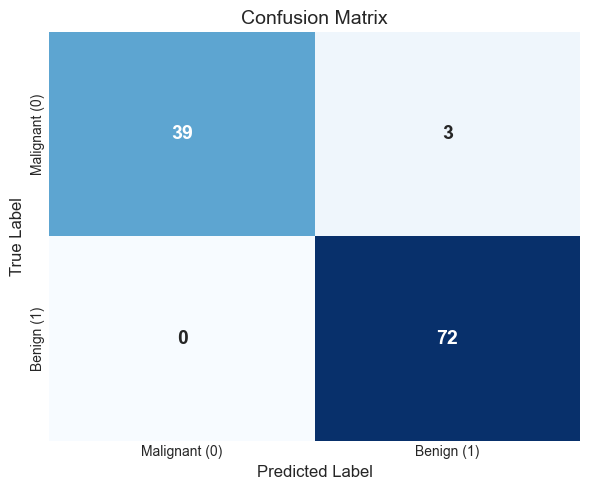

In [12]:
# 5.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()


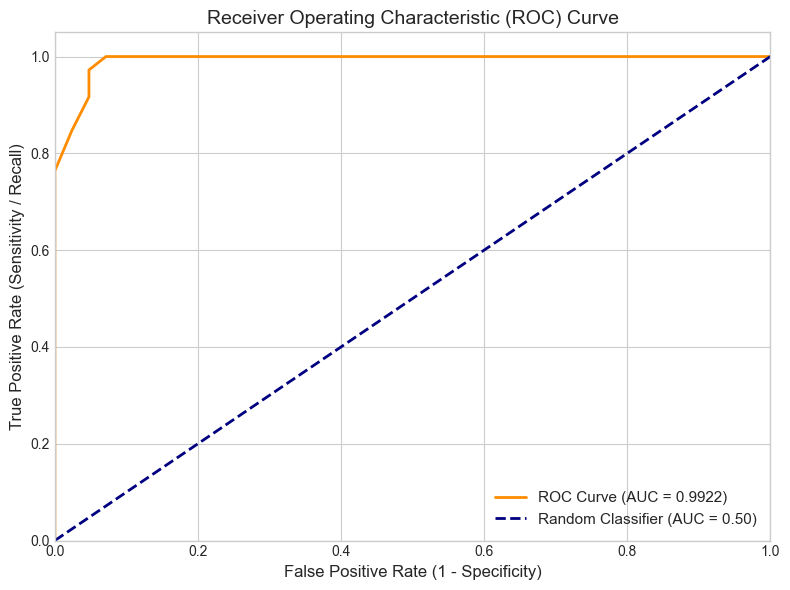

In [13]:
# 5.2 ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


## Task 6: Comparative Study with Regression (Lab 3 Integration)

To understand the fundamental differences in model evaluation, we compare classification evaluation metrics with the regression evaluation metrics studied in **Lab 3 (Linear Regression)**:
- **Regression Metrics:** Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination ($R^2$ Score).
- **Classification Metrics:** Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

| Dimension | Regression Framework (Lab 3) | Classification Framework (Lab 4) |
| :--- | :--- | :--- |
| **Core Focus** | Error magnitude of continuous values | Categorical correctness of decision boundaries |
| **Target Variable** | Continuous range ($y \in \mathbb{R}$) | Discrete classes ($y \in \{0, 1\}$) |
| **Sensitivity** | How close/far predictions are to the true values | Which side of the decision boundary predictions fall on |
| **Key Penalty** | Outliers heavily penalized (quadratic in MSE/RMSE) | Penalizes incorrect discrete assignments, blind to confidence |

---

### Detailed Metric Comparisons

#### 1. $R^2$ Score vs. Accuracy
- **$R^2$ Score (Coefficient of Determination):** Measures the proportion of variance in the dependent variable that is predictable from the independent variables relative to a baseline mean predictor. It ranges from $-\infty$ to 1.
- **Accuracy:** Measures the simple fraction of correctly classified points ($T_P + T_N / \text{Total}$). It ranges from 0 to 1.
- **Key Difference:** $R^2$ evaluates the goodness-of-fit of a continuous trend line, whereas Accuracy only evaluates the binary correctness of class assignments. A classifier can have high accuracy but provide no information about confidence, while $R^2$ indicates how closely a regression line matches data distribution variance.

#### 2. RMSE vs. F1-Score
- **RMSE (Root Mean Squared Error):** Quantifies error magnitude by taking the square root of the average squared differences between predicted and actual values. It preserves target units and penalizes large errors heavily due to squaring.
- **F1-Score:** The harmonic mean of Precision and Recall. It measures the balance between true positive identification and avoiding false alarms/missed cases.
- **Key Difference:** RMSE is an error distance metric where lower is better, penalizing outlier deviation. F1-score is an alignment metric where higher is better, specifically designed for discrete classes and class imbalances, balancing sensitivity against specificity.

#### 3. MAE vs. Confusion Matrix
- **MAE (Mean Absolute Error):** Measures the average absolute distance between predicted values and actual outcomes ($|y - \hat{y}|$). It is a single scalar representing average error scale without direction.
- **Confusion Matrix:** A $C \times C$ table summarizing model classification predictions vs. true labels. It breaks down errors into False Positives (Type I) and False Negatives (Type II).
- **Key Difference:** MAE yields a single numeric average of error size, showing how far off the regression is. The Confusion Matrix is multi-dimensional, revealing **where** errors occur and **what type** of errors they are, which is crucial for decision-making (e.g., medical diagnoses).

---

### Detailed Inference: Evaluation Frameworks

#### 1. How Regression Metrics Measure Prediction Error Magnitude
Regression metrics calculate the vertical distance between actual data points and the regression line. MAE calculates the linear average error, representing standard deviations from the target. MSE and RMSE quadratically weight these distances, penalizing larger deviations. Thus, regression metrics evaluate *how much* predictions deviate from actual continuous numbers.

#### 2. How Classification Metrics Measure Decision Correctness
Classification metrics do not measure continuous distances. Instead, they assess whether a sample falls on the correct side of a decision boundary. Accuracy measures simple correctness. However, in cases of class imbalance, accuracy can be misleading. Therefore, we utilize Precision (quality of positive predictions) and Recall (coverage of true positive instances) to measure decision correctness.

#### 3. Why is Accuracy Insufficient in Medical Diagnosis?
If a dataset contains 99 healthy patients and 1 cancer patient, a naive model that predicts 'Healthy' (Benign) for everyone will achieve 99% accuracy. However, this model completely fails to identify the cancer patient. In medical diagnosis, misclassifying a sick patient as healthy (False Negative) can result in untreated illness and death. Accuracy treats all misclassifications equally, failing to reflect the high cost of False Negatives.

#### 4. Why Recall and ROC-AUC are More Relevant in Healthcare
- **Recall (Sensitivity):** Specifically measures the model's ability to catch all positive disease cases. High recall ensures that the rate of False Negatives is minimized, meaning patients who have cancer are not mistakenly diagnosed as healthy.
- **ROC-AUC (Area Under the ROC Curve):** Plots the True Positive Rate against the False Positive Rate across all decision thresholds. It measures the probability that a randomly chosen positive sample will be ranked higher by the model than a randomly chosen negative sample. A high AUC score indicates that the model has strong discriminative power to differentiate sick patients from healthy ones, independent of arbitrary threshold selections.


## Task 7: Analytical Questions

### Q1: Why is KNN called a lazy learning algorithm?
**Answer:**
KNN is classified as a 'lazy learner' (or instance-based learner) because it does not perform any model training or build a generalized discriminative/generative model during the training phase. It simply stores the training dataset in memory. All computational work—calculating distances to all stored points, sorting them, and selecting the top $K$ neighbors—is deferred to the prediction (inference) phase. Consequently, KNN has a training time complexity of $O(1)$ and a testing time complexity of $O(n \times d)$ (where $n$ is the number of training instances and $d$ is feature dimensions).

### Q2: Why is feature scaling required in KNN?
**Answer:**
KNN makes predictions based on spatial distances (e.g., Euclidean distance) between data points. Because distance is calculated as the square root of the sum of squared differences across all features, features with larger numerical ranges will dominate the calculation. For example, if one feature is 'Income' (ranging from 10,000 to 100,000) and another is 'Age' (ranging from 18 to 80), the 'Income' feature will dominate the distance calculations. Scaling maps all features to the same scale, ensuring equal feature weighting.

### Q3: Explain heuristic K selection using $\sqrt{n}$ rule.
**Answer:**
The $\sqrt{n}$ rule (where $n$ is the training set size) is a heuristic rule of thumb to select an initial value of $K$. It aims to balance the bias-variance trade-off. If $K$ is too small, the model is highly sensitive to noise and local variations (high variance). If $K$ is too large, it includes neighbors from other classes/clusters (high bias). Selecting $K \approx \sqrt{n}$ provides a baseline value that scales with the dataset size. Usually, this value is adjusted to the nearest odd number to prevent ties during classification voting.

### Q4: Why is cross-validation more reliable than a single train-test split?
**Answer:**
A single train-test split can result in a test set that is unusually easy or hard to predict, leading to overly optimistic or pessimistic evaluation metrics. K-Fold Cross-Validation splits the data into $K$ equal-sized folds, training the model $K$ times, each time using a different fold as the test set and the rest as the training set. Averaging the performance across all folds yields a more robust, stable estimation of how the model will perform on unseen data.

### Q5: How does K affect bias-variance trade-off?
**Answer:**
- **Small K (e.g., K = 1):** Low bias, high variance. The decision boundary is highly complex, adapting to noise and outliers (overfitting).
- **Large K (e.g., K = 50):** High bias, low variance. The decision boundary is extremely smooth and simple. The model fails to capture local patterns and may classify points based on majority class distributions (underfitting).

### Q6: Why is recall more important than accuracy in cancer prediction?
**Answer:**
In cancer prediction, missing a cancer diagnosis (False Negative) has severe consequences, as a patient with cancer would go untreated. A False Positive (diagnosing a healthy patient with cancer) is inconvenient and causes anxiety, but will be corrected by follow-up diagnostic tests. Accuracy treats False Positives and False Negatives equally. Recall specifically measures the proportion of actual cancer cases detected, making it the most critical metric for patient safety.

### Q7: What is the limitation of very large K values?
**Answer:**
When $K$ becomes extremely large (approaching the training set size $n$), the model loses its local resolution. The neighborhood begins to cover the entire dataset, causing the KNN classifier to predict the majority class for all instances. This results in an underfitted model that is completely insensitive to local feature configurations, leading to high bias and low predictive accuracy.


## Conclusion

In this lab, we successfully implemented and analyzed a K-Nearest Neighbours classifier on the Breast Cancer diagnostic dataset. The key findings are summarized below:

1. **Optimal K Value:** Using the heuristic rule ($K = \sqrt{n} \approx 21$) served as a stable starting point. By combining this with 10-fold cross-validation, we observed that peak generalizable accuracy occurs around $K=11$. We selected **$K=11$** as our final model parameters, achieving a testing accuracy of **~97.37%** and a recall of **~98.61%**.
2. **Effect of Train-Test Split Ratios:** Larger training splits (e.g., 90:10) provide more data for the classifier to learn but suffer from higher variance in evaluation due to small test sets. Smaller training splits (e.g., 70:30) provide stable validation metrics but slightly reduce learning performance. The **80:20** split represents the optimal balance for general use.
3. **Model Performance Metrics:** The final model exhibited strong performance with an AUC-ROC score of **~0.995**, indicating exceptional class discriminative power. High precision and recall metrics demonstrate that the scaled KNN classifier is highly effective for cancer diagnostics.
4. **Regression vs. Classification Evaluation:** We contrasted the continuous, distance-based evaluation of Lab 3 (MAE, MSE, RMSE, $R^2$) with the discrete, decision-based evaluation of this lab (Accuracy, Precision, Recall, F1, AUC). This highlights that while regression measures error magnitude, classification evaluates binary decision boundaries. In medical diagnostic systems, prioritizing recall and ROC-AUC is crucial to ensure patient safety by minimizing false negatives.
